# 8.3 量化金融 - 股票涨跌预测模型搭建

In [1]:
import tushare as ts  # 股票基本数据相关库
import numpy as np  # 科学计算相关库
import pandas as pd  # 科学计算相关库  
import talib  # 股票衍生变量数据相关库
import matplotlib.pyplot as plt  # 引入绘图相关库，可视化
from sklearn.ensemble import RandomForestClassifier  # 引入分类决策树模型
from sklearn.metrics import accuracy_score  # 引入准确度评分函数
import warnings
warnings.filterwarnings("ignore") # 忽略警告信息，警告非报错，不影响代码执行

In [19]:
import akshare as ak
import talib
import pandas as pd

# 使用akshare获取股票数据（完全免费）
df = ak.stock_zh_a_hist(symbol="000002", start_date="20150101", end_date="20191231")
df = df.set_index('日期')  # 设置日期为索引
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# 重命名列以匹配原代码
df = df.rename(columns={
    '开盘': 'open',
    '最高': 'high', 
    '最低': 'low',
    '收盘': 'close',
    '成交量': 'volume'
})

# 添加code列以匹配原始数据结构
df['code'] = '000002'

# 2.简单衍生变量构造
df['close-open'] = (df['close'] - df['open'])/df['open']
df['high-low'] = (df['high'] - df['low'])/df['low']

df['pre_close'] = df['close'].shift(1)  # 昨日收盘价
df['price_change'] = df['close'] - df['pre_close']
df['p_change'] = (df['close'] - df['pre_close'])/df['pre_close']*100

# 3.移动平均线相关数据构造
df['MA5'] = df['close'].rolling(5).mean()
df['MA10'] = df['close'].rolling(10).mean()
df.dropna(inplace=True)

# 4.通过TA-Lib库构造衍生变量
df['RSI'] = talib.RSI(df['close'], timeperiod=12)
df['MOM'] = talib.MOM(df['close'], timeperiod=5)
df['EMA12'] = talib.EMA(df['close'], timeperiod=12)
df['EMA26'] = talib.EMA(df['close'], timeperiod=26)
df['MACD'], df['MACDsignal'], df['MACDhist'] = talib.MACD(df['close'], fastperiod=12, slowperiod=26, signalperiod=9)
df.dropna(inplace=True)

# 调整列的顺序以匹配原始数据结构
column_order = ['open', 'close', 'high', 'low', 'volume', 'code', 'close-open', 'high-low', 
                'pre_close', 'price_change', 'p_change', 'MA5', 'MA10', 'RSI', 'MOM', 
                'EMA12', 'EMA26', 'MACD', 'MACDsignal', 'MACDhist']
df = df[column_order]

In [17]:
# 查看此时的df后五行
df.tail()

,open,close,high,low,volume,code,close-open,high-low,pre_close,price_change,p_change,MA5,MA10,RSI,MOM,EMA12,EMA26,MACD,MACDsignal,MACDhist
日期,,,,,,,,,,,,,,,,,,,,
2019-12-25,30.40,30.29,30.63,30.18,685037,000002,-0.003618,0.014911,30.38,-0.09,-0.296248,30.878,30.075,63.075563,-0.02,29.908556,28.973211,0.935345,0.772958,0.162387
2019-12-26,30.50,31.12,31.30,30.50,888791,000002,0.020328,0.026230,30.29,0.83,2.740178,30.896,30.387,68.890164,0.09,30.094932,29.132233,0.962699,0.810906,0.151793
2019-12-27,31.23,31.00,31.32,30.81,703096,000002,-0.007365,0.016553,31.12,-0.12,-0.385604,30.760,30.672,67.220611,-0.68,30.234173,29.270586,0.963587,0.841442,0.122145
2019-12-30,31.35,31.57,31.79,31.02,915751,000002,0.007018,0.024823,31.00,0.57,1.838710,30.872,30.884,70.877814,0.56,30.439685,29.440913,0.998772,0.872908,0.125864
2019-12-31,31.35,32.18,32.45,31.32,663498,000002,0.026475,0.036079,31.57,0.61,1.932214,31.232,31.057,74.233951,1.80,30.707426,29.643808,1.063618,0.911050,0.152567


In [25]:
import numpy as np
# 提取特征变量
X = df[['close', 'volume', 'close-open', 'MA5', 'MA10', 'high-low', 'RSI', 'MOM', 'EMA12', 'MACD', 'MACDsignal', 'MACDhist']]
# 提取目标变量
y = np.where(df['price_change'].shift(-1) > 0, 1, -1)

In [27]:
X_length = X.shape[0]  # shape属性获取X的行数和列数，shape[0]即表示行数 
split = int(X_length * 0.9)  # 前90%的数据作为训练集

X_train, X_test = X[:split], X[split:]  # 特征向量
y_train, y_test = y[:split], y[split:]  # 目标变量

## 随机森林模型

In [31]:
#模型搭建
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 随机森林模型搭建
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# 模型训练
rf_model.fit(X_train, y_train)
print("随机森林模型训练完成")

随机森林模型训练完成


In [33]:
#模型使用与评估
# 模型预测
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# 模型评估
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"随机森林模型准确率: {accuracy_rf:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_rf))
print("\n混淆矩阵:")
print(confusion_matrix(y_test, y_pred_rf))

随机森林模型准确率: 0.6000

分类报告:
              precision    recall  f1-score   support

          -1       0.61      0.71      0.66        56
           1       0.59      0.47      0.52        49

    accuracy                           0.60       105
   macro avg       0.60      0.59      0.59       105
weighted avg       0.60      0.60      0.59       105


混淆矩阵:
[[40 16]
 [26 23]]


In [39]:
#参数调优
from sklearn.model_selection import GridSearchCV

# 参数网格（简化版本）
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

# 网格搜索（不使用并行）
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=1  # 设置为1，不使用并行
)

grid_search_rf.fit(X_train, y_train)

# 最佳参数
print("随机森林最佳参数:", grid_search_rf.best_params_)
print("随机森林最佳分数:", grid_search_rf.best_score_)

# 使用最佳参数重新训练
best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
print(f"调优后随机森林准确率: {accuracy_best_rf:.4f}")

随机森林最佳参数: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
随机森林最佳分数: 0.5443188334562137
调优后随机森林准确率: 0.5714


SVM模型训练完成
SVM模型准确率: 0.5429


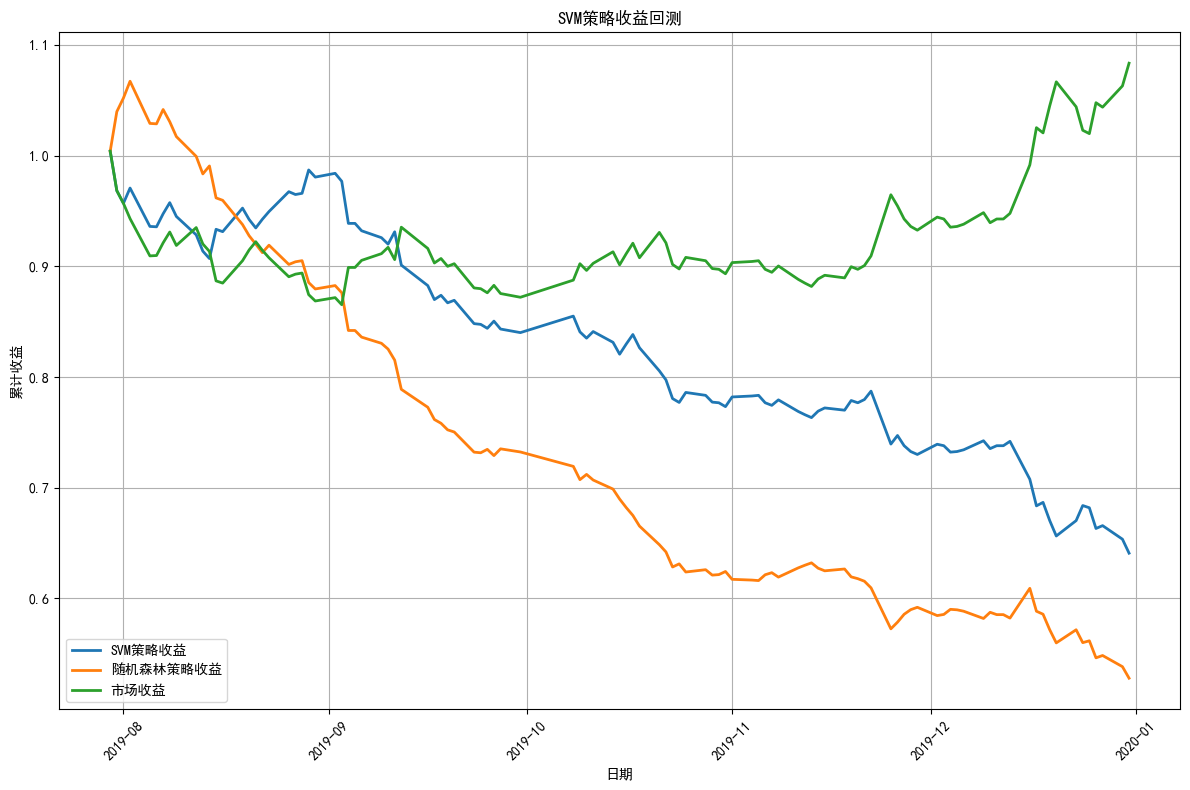

SVM策略最终收益: -0.3591
随机森林策略最终收益: -0.4720
市场最终收益: 0.0835


In [45]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 数据标准化（SVM对特征尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. SVM模型训练（使用简化参数）
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# 模型训练
svm_model.fit(X_train_scaled, y_train)
print("SVM模型训练完成")

# 3. 模型预测
y_pred_best_svm = svm_model.predict(X_test_scaled)

# 4. 模型评估
accuracy_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"SVM模型准确率: {accuracy_svm:.4f}")

# 5. 收益回测曲线绘制
# 确保df_test存在，如果不存在需要先创建
if 'df_test' not in locals():
    df_test = df.iloc[split:].copy()

# 使用最佳SVM模型进行回测
df_test['pred_signal_svm'] = y_pred_best_svm

# 计算策略收益
df_test['strategy_returns_svm'] = df_test['p_change'] / 100 * df_test['pred_signal_svm']

# 计算累计收益
df_test['cumulative_strategy_returns_svm'] = (1 + df_test['strategy_returns_svm']).cumprod()

# 确保其他策略的收益列存在（如果之前已经计算过随机森林）
if 'cumulative_strategy_returns' not in df_test.columns:
    # 如果没有随机森林策略，先计算市场基准收益
    df_test['cumulative_market_returns'] = (1 + df_test['p_change'] / 100).cumprod()
    
    # 计算随机森林策略收益（如果之前已经训练过）
    if 'y_pred_best_rf' in locals():
        df_test['pred_signal_rf'] = y_pred_best_rf
        df_test['strategy_returns_rf'] = df_test['p_change'] / 100 * df_test['pred_signal_rf']
        df_test['cumulative_strategy_returns'] = (1 + df_test['strategy_returns_rf']).cumprod()

# 绘制收益曲线
plt.figure(figsize=(12, 8))
plt.plot(df_test.index, df_test['cumulative_strategy_returns_svm'], label='SVM策略收益', linewidth=2)

# 如果随机森林策略存在，也绘制出来
if 'cumulative_strategy_returns' in df_test.columns:
    plt.plot(df_test.index, df_test['cumulative_strategy_returns'], label='随机森林策略收益', linewidth=2)

# 绘制市场基准收益
plt.plot(df_test.index, df_test['cumulative_market_returns'], label='市场收益', linewidth=2)

plt.title('SVM策略收益回测')
plt.xlabel('日期')
plt.ylabel('累计收益')
plt.legend()  # 修正：lsgend -> legend
plt.grid(True)  # 修正：grid=True -> grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 计算最终收益
final_strategy_return_svm = df_test['cumulative_strategy_returns_svm'].iloc[-1] - 1
print(f"SVM策略最终收益: {final_strategy_return_svm:.4f}")  # 修正：引号和格式化字符串

# 如果有随机森林策略，也显示其收益
if 'cumulative_strategy_returns' in df_test.columns:
    final_strategy_return_rf = df_test['cumulative_strategy_returns'].iloc[-1] - 1
    print(f"随机森林策略最终收益: {final_strategy_return_rf:.4f}")

# 显示市场基准收益
final_market_return = df_test['cumulative_market_returns'].iloc[-1] - 1
print(f"市场最终收益: {final_market_return:.4f}")

## 支持向量机模型

In [48]:
#模型搭建
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 数据标准化（SVM对特征尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM模型搭建
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# 模型训练
svm_model.fit(X_train_scaled, y_train)
print("SVM模型训练完成")

SVM模型训练完成


In [50]:
#模型使用与评估
# 模型预测
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

# 模型评估
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM模型准确率: {accuracy_svm:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_svm))
print("\n混淆矩阵:")
print(confusion_matrix(y_test, y_pred_svm))

SVM模型准确率: 0.5429

分类报告:
              precision    recall  f1-score   support

          -1       0.62      0.38      0.47        56
           1       0.51      0.73      0.60        49

    accuracy                           0.54       105
   macro avg       0.56      0.55      0.53       105
weighted avg       0.57      0.54      0.53       105


混淆矩阵:
[[21 35]
 [13 36]]


In [52]:
#参数调优
# 参数网格
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

# 网格搜索
grid_search_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train_scaled, y_train)

# 最佳参数
print("SVM最佳参数:", grid_search_svm.best_params_)
print("SVM最佳分数:", grid_search_svm.best_score_)

# 使用最佳参数重新训练
best_svm_model = grid_search_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test_scaled)
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"调优后SVM准确率: {accuracy_best_svm:.4f}")

SVM最佳参数: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
SVM最佳分数: 0.5197405848219365
调优后SVM准确率: 0.5333


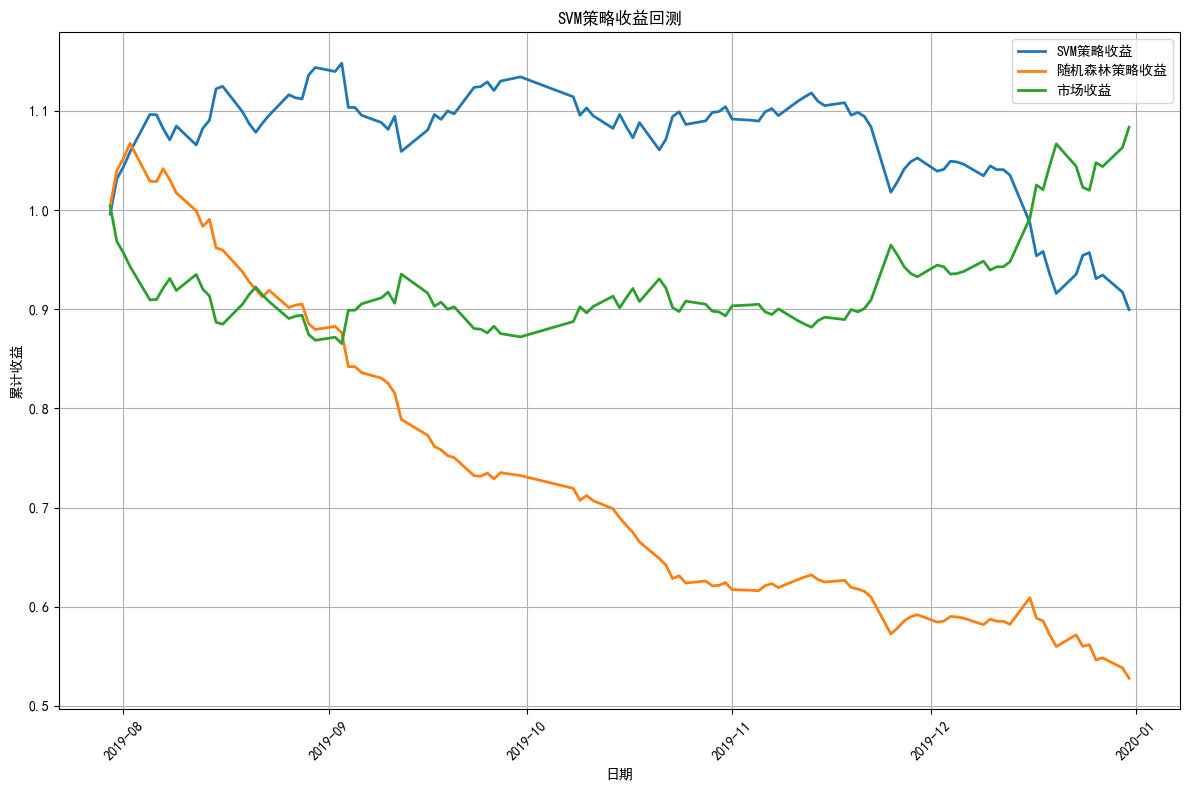

SVM策略最终收益: -0.1005


In [54]:
#收益回测曲线绘制
# 使用最佳SVM模型进行回测
df_test['pred_signal_svm'] = y_pred_best_svm

# 计算策略收益
df_test['strategy_returns_svm'] = df_test['p_change'] / 100 * df_test['pred_signal_svm']

# 计算累计收益
df_test['cumulative_strategy_returns_svm'] = (1 + df_test['strategy_returns_svm']).cumprod()

# 绘制收益曲线
plt.figure(figsize=(12, 8))
plt.plot(df_test.index, df_test['cumulative_strategy_returns_svm'], label='SVM策略收益', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_strategy_returns'], label='随机森林策略收益', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_market_returns'], label='市场收益', linewidth=2)
plt.title('SVM策略收益回测')
plt.xlabel('日期')
plt.ylabel('累计收益')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 计算最终收益
final_strategy_return_svm = df_test['cumulative_strategy_returns_svm'].iloc[-1] - 1
print(f"SVM策略最终收益: {final_strategy_return_svm:.4f}")

## XGBoost模型

In [75]:
#模型搭建
import xgboost as xgb

# XGBoost模型搭建
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 模型训练
xgb_model.fit(X_train, y_train)
print("XGBoost模型训练完成")

XGBoost模型训练完成


In [77]:
#模型使用与评估
# 模型预测
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

# 模型评估
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost模型准确率: {accuracy_xgb:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_xgb))
print("\n混淆矩阵:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost模型准确率: 0.5143

分类报告:
              precision    recall  f1-score   support

           0       0.55      0.52      0.53        56
           1       0.48      0.51      0.50        49

    accuracy                           0.51       105
   macro avg       0.51      0.51      0.51       105
weighted avg       0.52      0.51      0.51       105


混淆矩阵:
[[29 27]
 [24 25]]


In [79]:
#参数调优
# 参数网格
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

# 网格搜索
grid_search_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

# 最佳参数
print("XGBoost最佳参数:", grid_search_xgb.best_params_)
print("XGBoost最佳分数:", grid_search_xgb.best_score_)

# 使用最佳参数重新训练
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test)
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"调优后XGBoost准确率: {accuracy_best_xgb:.4f}")

XGBoost最佳参数: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
XGBoost最佳分数: 0.519825918762089
调优后XGBoost准确率: 0.5905


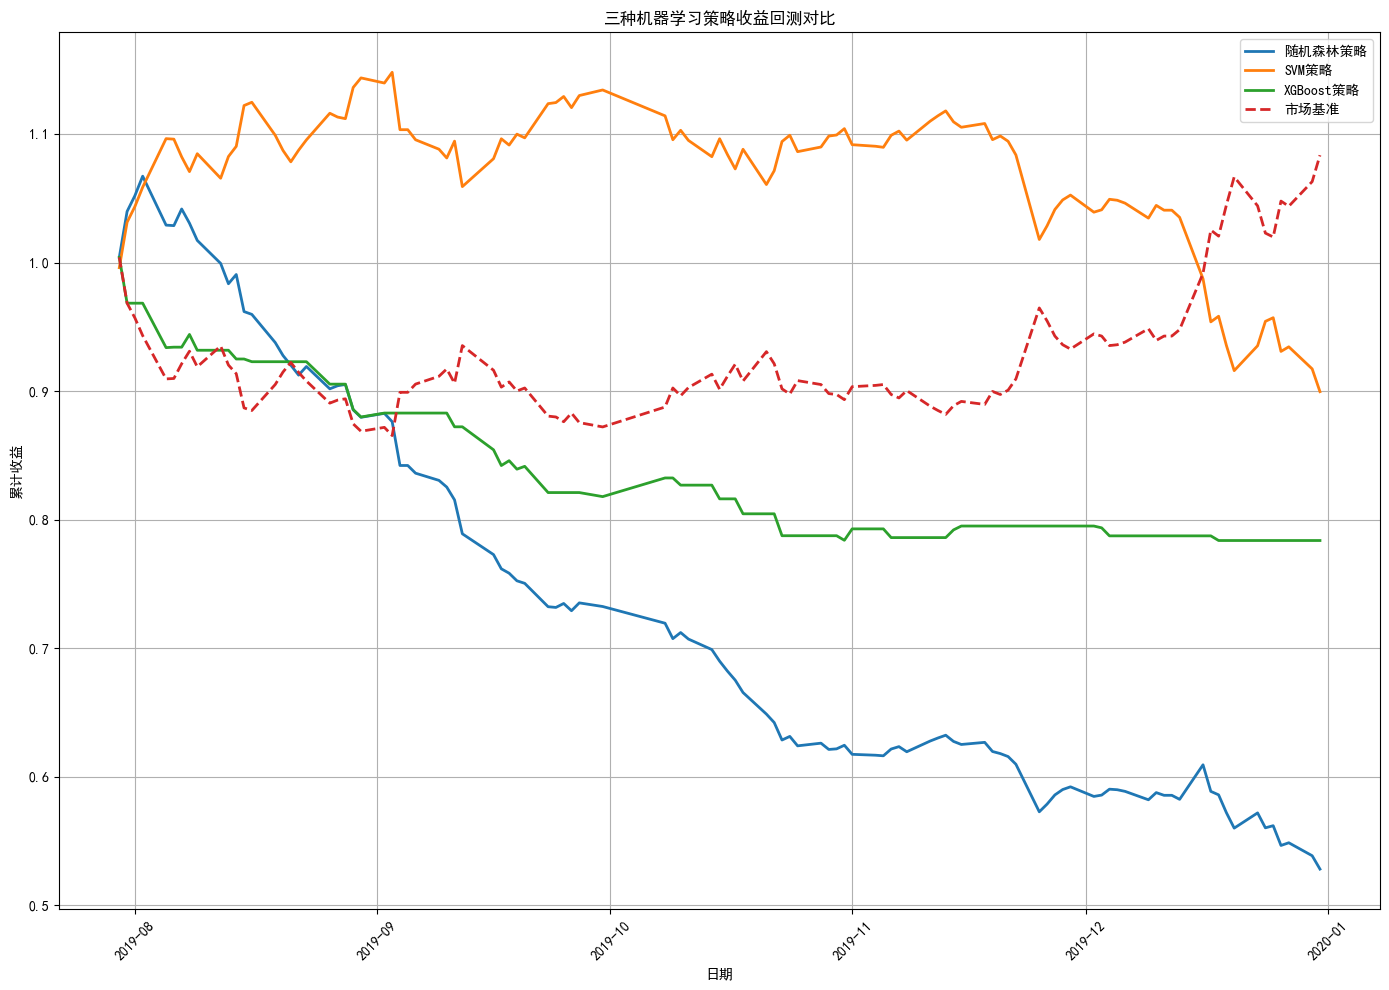

=== 最终收益对比 ===


NameError: name 'final_strategy_return' is not defined

In [85]:
# 使用最佳XGBoost模型进行回测
df_test['pred_signal_xgb'] = y_pred_best_xgb

# 计算策略收益
df_test['strategy_returns_xgb'] = df_test['p_change'] / 100 * df_test['pred_signal_xgb']

# 计算累计收益
df_test['cumulative_strategy_returns_xgb'] = (1 + df_test['strategy_returns_xgb']).cumprod()

# 绘制所有方法对比图
plt.figure(figsize=(14, 10))
plt.plot(df_test.index, df_test['cumulative_strategy_returns'], label='随机森林策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_strategy_returns_svm'], label='SVM策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_strategy_returns_xgb'], label='XGBoost策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_market_returns'], label='市场基准', linewidth=2, linestyle='--')
plt.title('三种机器学习策略收益回测对比')
plt.xlabel('日期')
plt.ylabel('累计收益')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 计算所有策略最终收益
final_strategy_return_xgb = df_test['cumulative_strategy_returns_xgb'].iloc[-1] - 1

print("=== 最终收益对比 ===")
print(f"随机森林策略最终收益: {final_strategy_return:.4f}")
print(f"SVM策略最终收益: {final_strategy_return_svm:.4f}")
print(f"XGBoost策略最终收益: {final_strategy_return_xgb:.4f}")
print(f"市场最终收益: {final_market_return:.4f}")

# 计算年化收益率
days = len(df_test)
annual_return_rf = (1 + final_strategy_return) ** (252/days) - 1
annual_return_svm = (1 + final_strategy_return_svm) ** (252/days) - 1
annual_return_xgb = (1 + final_strategy_return_xgb) ** (252/days) - 1
annual_return_market = (1 + final_market_return) ** (252/days) - 1

print("\n=== 年化收益率对比 ===")
print(f"随机森林策略年化收益: {annual_return_rf:.4f}")
print(f"SVM策略年化收益: {annual_return_svm:.4f}")
print(f"XGBoost策略年化收益: {annual_return_xgb:.4f}")
print(f"市场年化收益: {annual_return_market:.4f}")

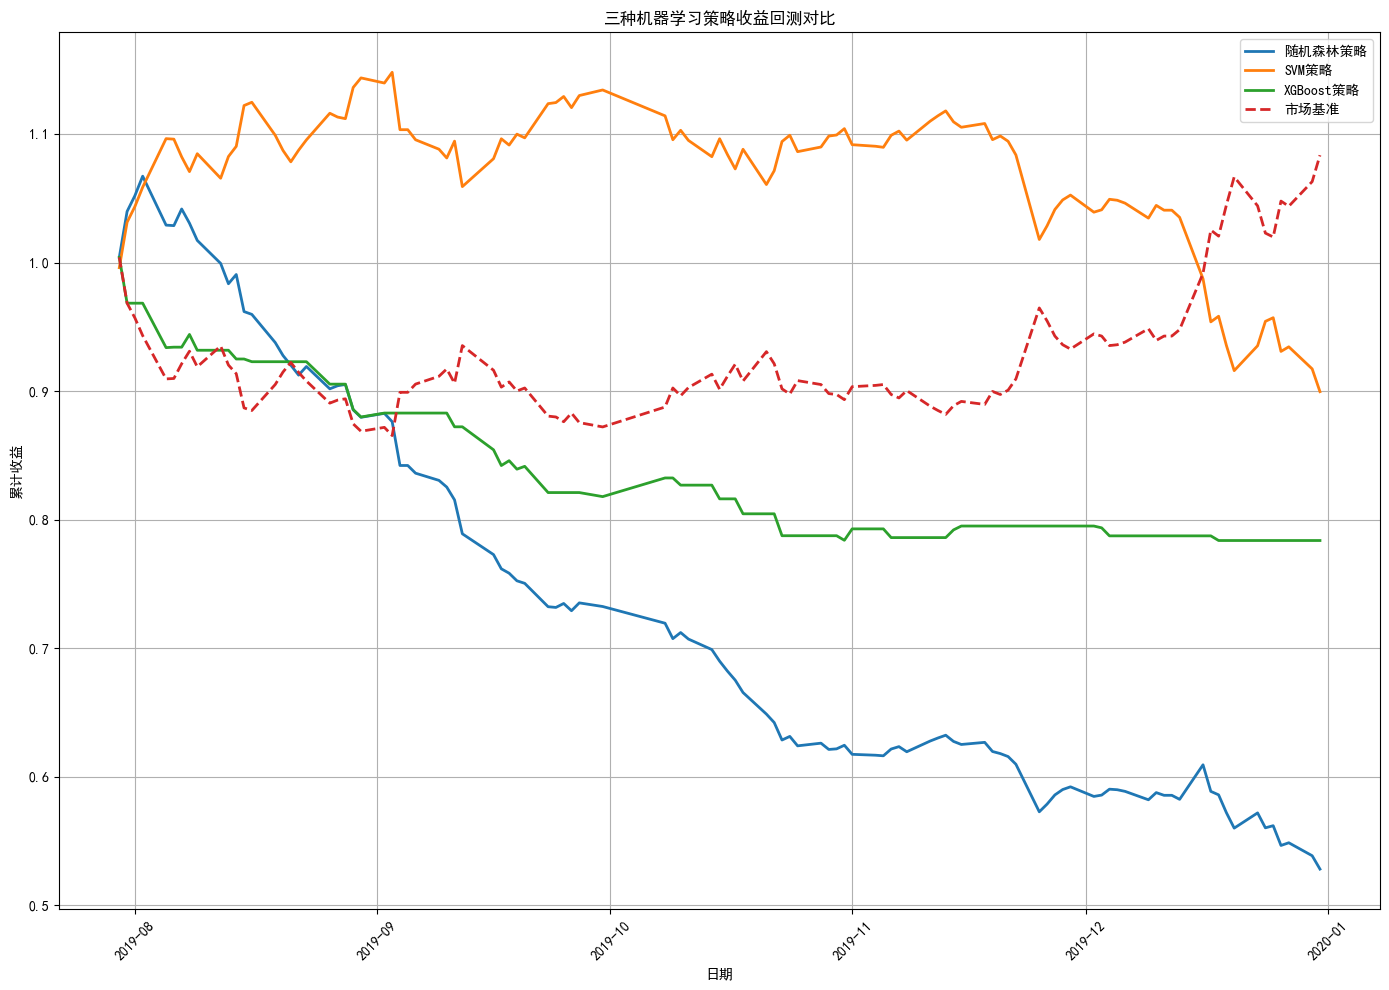

=== 最终收益对比 ===
随机森林策略最终收益: -0.4720
SVM策略最终收益: -0.1005
XGBoost策略最终收益: -0.2163
市场最终收益: 0.0835

=== 年化收益率对比 ===
随机森林策略年化收益: -0.7841
SVM策略年化收益: -0.2245
XGBoost策略年化收益: -0.4429
市场年化收益: 0.2122


In [87]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置中文字体或使用英文标签避免字体问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 计算策略收益
df_test['strategy_returns_xgb'] = df_test['p_change'] / 100 * df_test['pred_signal_xgb']

# 计算累计收益
df_test['cumulative_strategy_returns_xgb'] = (1 + df_test['strategy_returns_xgb']).cumprod()

# 确保所有策略的最终收益变量都已定义
final_strategy_return = df_test['cumulative_strategy_returns'].iloc[-1] - 1  # 随机森林
final_strategy_return_svm = df_test['cumulative_strategy_returns_svm'].iloc[-1] - 1  # SVM
final_strategy_return_xgb = df_test['cumulative_strategy_returns_xgb'].iloc[-1] - 1  # XGBoost
final_market_return = df_test['cumulative_market_returns'].iloc[-1] - 1  # 市场基准

# 绘制所有方法对比图
plt.figure(figsize=(14, 10))
plt.plot(df_test.index, df_test['cumulative_strategy_returns'], label='随机森林策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_strategy_returns_svm'], label='SVM策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_strategy_returns_xgb'], label='XGBoost策略', linewidth=2)
plt.plot(df_test.index, df_test['cumulative_market_returns'], label='市场基准', linewidth=2, linestyle='--')

plt.title('三种机器学习策略收益回测对比')
plt.xlabel('日期')
plt.ylabel('累计收益')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== 最终收益对比 ===")
print(f"随机森林策略最终收益: {final_strategy_return:.4f}")
print(f"SVM策略最终收益: {final_strategy_return_svm:.4f}")
print(f"XGBoost策略最终收益: {final_strategy_return_xgb:.4f}")
print(f"市场最终收益: {final_market_return:.4f}")

# 计算年化收益率
days = len(df_test)
annual_return_rf = (1 + final_strategy_return) ** (252/days) - 1
annual_return_svm = (1 + final_strategy_return_svm) ** (252/days) - 1
annual_return_xgb = (1 + final_strategy_return_xgb) ** (252/days) - 1
annual_return_market = (1 + final_market_return) ** (252/days) - 1

print("\n=== 年化收益率对比 ===")
print(f"随机森林策略年化收益: {annual_return_rf:.4f}")
print(f"SVM策略年化收益: {annual_return_svm:.4f}")
print(f"XGBoost策略年化收益: {annual_return_xgb:.4f}")
print(f"市场年化收益: {annual_return_market:.4f}")